# MTH9877 — Assignment 3: Part E(ii) — Time-Varying Covariates

**Standalone notebook.**  Requires the three processed parquet files in `processed/`.

In [7]:
import polars as pl
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from lifelines import (
    AalenJohansenFitter,
    KaplanMeierFitter,
    CoxPHFitter,
    CoxTimeVaryingFitter,
)
from lifelines.utils import concordance_index
from scipy.ndimage import gaussian_filter1d
warnings.filterwarnings("ignore")

BASE          = Path("/Users/yueqilin/Desktop/MTH9877 IR/IR&C Assignment3")
OUT_DIR       = BASE / "processed"
SURVIVAL_PATH = OUT_DIR / "survival_loans.parquet"
MACRO_PATH    = OUT_DIR / "macro_monthly.parquet"
PANEL_PATH    = OUT_DIR / "panel_monthly.parquet"

# ── Partner A-D paths ─────────────────────────────────────────────────────────
ATOD_BASE  = BASE / "AtoD"
ATOD_CANON = ATOD_BASE / "results_cd/canonical_split.parquet"

# Part B concordance benchmarks (partner's full-dataset Cox, 1.85M training loans)
PARTB_CI_BASE  = 0.6257   # base Cox (15 covariates)
PARTB_CI_MACRO = 0.6428   # macro Cox (+4 FRED vars: Treasury10Y, Unemployment, HPI, MortgageRate)

# Model colours (partner's palette)
MODEL_COLORS = {
    "LogReg":    "#9CA3AF",
    "RF":        "#16A34A",
    "LGBM":      "#EA580C",
    "Cox":       "#2563EB",
    "LinearCox": "#7C3AED",
    "DeepCox":   "#DC2626",
}

DEVICE = (
    torch.device("mps")  if torch.backends.mps.is_available() else
    torch.device("cuda") if torch.cuda.is_available() else
    torch.device("cpu")
)
print(f"Device : {DEVICE}")
for p in [SURVIVAL_PATH, MACRO_PATH, PANEL_PATH, ATOD_CANON]:
    status = "OK" if p.exists() else "MISSING"
    print(f"  [{status}] {p.name}")

# ── Plot style — aligned with partner's apply_plot_style() ───────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.labelsize":   12,
    "legend.fontsize":  10,
    "figure.dpi":       150,
})

Device : mps
  [OK] survival_loans.parquet
  [OK] macro_monthly.parquet
  [OK] panel_monthly.parquet
  [OK] canonical_split.parquet


## Setup — Load Data & Train Models

Loads the three parquet files and builds the working datasets used throughout:

| Variable | Contents | Used by |
|---|---|---|
| `survival` | 34M loans, one row each | EDA (full dataset) |
| `sv_sub` | 100K stratified sample | AJ CIF, Cox models, scenario analysis |
| `macro` | Monthly macro (1999–2025) | Deep Cox, cause-specific Cox, E(ii) |
| `dc_df` | sv_sub + annual macro | Deep Cox training |
| `FEATURES` / `xgb_model` | Panel-trained XGBoost | E(iv) scenario analysis |


In [8]:
# ── Survival dataset + 100K stratified subsample ─────────────────────────────
survival = pl.read_parquet(SURVIVAL_PATH)
print(f"Full dataset : {survival.height:,} loans")

B_SAMPLE_N = 100_000
sv_sub = (
    survival
    .with_columns(pl.col("VintageYear").cast(pl.Int32))
    .group_by("VintageYear")
    .map_groups(lambda g: g.sample(
        n=min(len(g), max(1, int(B_SAMPLE_N * len(g) / survival.height))),
        seed=42
    ))
).to_pandas()
print(f"Subsample    : {len(sv_sub):,} loans  (stratified by vintage year)")

# ── Macro covariates ──────────────────────────────────────────────────────────
macro = pl.read_parquet(MACRO_PATH)
print(f"Macro rows   : {macro.height:,}  columns: {macro.columns}")

Full dataset : 34,013,469 loans
Subsample    : 99,986 loans  (stratified by vintage year)
Macro rows   : 324  columns: ['yyyymm', 'mortgage_rate', 'unemployment', 'cpi_yoy', 'hpi_yoy']


---
## E(ii) — Time-Dependent Covariates

Standard Cox models fix covariates at origination. In reality the key drivers of
prepayment and default — **mortgage rates, unemployment, and the rate incentive** —
evolve every month. The **Andersen-Gill counting-process** extension handles this:
each loan contributes one row per calendar period, with that period's covariate values.

| Model | Covariate assumption | Data format |
|---|---|---|
| Standard Cox — E(i)(e) | Fixed at origination vintage | One row per loan |
| **Andersen-Gill Cox — E(ii)** | Updated each month | One row per loan-month |

**Key question**: does using *current* `rate_incentive` (orig_rate − today's rate) rather
than the origination-vintage snapshot improve the prepayment hazard estimate?

**Motivating example**: a 2020-vintage borrower locked in at 3% faces a rate incentive
of ~+3 pp at origination — a strong refi signal. By 2023, as market rates rose to 7%,
the same loan's incentive collapsed to −4 pp, killing the refi option entirely.
A static model using the 2020 vintage-average rate sees the strong origination signal
and never learns that the option went underwater — the Andersen-Gill model does.

**Data**: 100,000 loans sampled from the monthly panel (stratified by vintage year),
yielding ~4.7M loan-month rows with `(tstart, tstop, event)` intervals per loan.

In [9]:
TV_LOANS = 100_000

# ── Sample 50K loans from panel (stratified by vintage_year) ──────────────────
panel_full = pl.read_parquet(PANEL_PATH)
loan_meta = (
    panel_full
    .group_by("loan_id")
    .agg(pl.col("vintage_year").first())
)
tv_loan_ids = (
    loan_meta
    .group_by("vintage_year")
    .map_groups(lambda g: g.sample(
        n=min(len(g), max(1, int(TV_LOANS * len(g) / loan_meta.height))),
        seed=42
    ))
)["loan_id"].to_list()
print(f"TV loans sampled: {len(tv_loan_ids):,}")

# ── Filter panel to sampled loans ─────────────────────────────────────────────
tv_panel = panel_full.filter(pl.col("loan_id").is_in(tv_loan_ids))
print(f"TV rows: {tv_panel.height:,}  "
      f"prepay events: {tv_panel['prepaid_month'].sum():,}")

# ── Convert to pandas counting-process format ─────────────────────────────────
df_tv = tv_panel.to_pandas()
df_tv = df_tv.sort_values(["loan_id", "loan_age"]).reset_index(drop=True)
df_tv["tstart"] = df_tv["loan_age"]
df_tv["tstop"]  = df_tv["loan_age"] + 1

# ── Synthetic current LTV (ELTV) — remaining balance fraction ─────────────────
r_mo = (df_tv["orig_rate"] / 100 / 12).clip(lower=1e-6)
t    = df_tv["loan_age"].values
numer = (1 + r_mo) ** 360 - (1 + r_mo) ** t
denom = (1 + r_mo) ** 360 - 1
df_tv["remaining_pct"] = (numer.values / denom.values).clip(0, 1)

# ── HPI cumulative product via Polars (~10x faster than pandas groupby.cumprod) ──
_hpi_pl = (
    pl.from_pandas(
        df_tv[["loan_id", "loan_age", "hpi_yoy", "LTV", "remaining_pct"]]
        .assign(hpi_yoy=df_tv["hpi_yoy"].fillna(0))
    )
    .sort(["loan_id", "loan_age"])
    .with_columns((1.0 + pl.col("hpi_yoy") / 1200.0).alias("_hpi_factor"))
    .with_columns(pl.col("_hpi_factor").cum_prod().over("loan_id").alias("hpi_cumul"))
    .with_columns(
        (pl.col("LTV") * pl.col("remaining_pct") / pl.col("hpi_cumul"))
        .clip(0, 200).alias("ELTV")
    )
)
df_tv["ELTV"] = _hpi_pl["ELTV"].to_numpy()
df_tv.drop(columns=["remaining_pct"], inplace=True)

# ── One-hot encode categoricals ───────────────────────────────────────────────
df_tv["LP_Purchase"]    = (df_tv["loan_purpose"] == "P").astype(float)
df_tv["LP_NoCashRefi"]  = (df_tv["loan_purpose"] == "N").astype(float)
df_tv["Occ_Investment"] = (df_tv["occupancy"] == "I").astype(float)
df_tv["Occ_SecondHome"] = (df_tv["occupancy"] == "S").astype(float)
df_tv["DTI"] = df_tv["DTI"].replace(999.0, np.nan)

# orig_rate is a loan-level constant — included in TV_STATIC so both models share it.
# TV Cox uses it alongside rate_incentive(t) to decompose coupon level from live spread.
# Static Cox uses it as the primary rate-era proxy (replaces the degenerate rate_incentive≈0).
TV_STATIC  = ["FICO", "LTV", "DTI", "UPB", "orig_rate",
               "LP_Purchase", "LP_NoCashRefi", "Occ_Investment", "Occ_SecondHome"]
# mortgage_rate excluded: rate_incentive = orig_rate − mortgage_rate is perfectly
# collinear with mortgage_rate within each loan's time series (orig_rate is fixed).
TV_DYNAMIC = ["ELTV", "unemployment", "hpi_yoy", "rate_incentive"]
TV_FEATS   = TV_STATIC + TV_DYNAMIC

# Static Cox uses TV_STATIC (incl. orig_rate) + origination-era macro.
# Excludes ELTV (= LTV at origination, collinear) and rate_incentive (≈ 0 at origination).
STATIC_FEATS = TV_STATIC + ["unemployment", "hpi_yoy"]

df_tv[TV_FEATS] = df_tv[TV_FEATS].fillna(df_tv[TV_FEATS].median())
scaler_tv = StandardScaler()
df_tv[TV_FEATS] = scaler_tv.fit_transform(df_tv[TV_FEATS])

print(f"TV Cox  : {len(TV_FEATS)} features")
print(f"Static  : {len(STATIC_FEATS)} features  (orig_rate in TV_STATIC, shared by both)")

KeyboardInterrupt: 

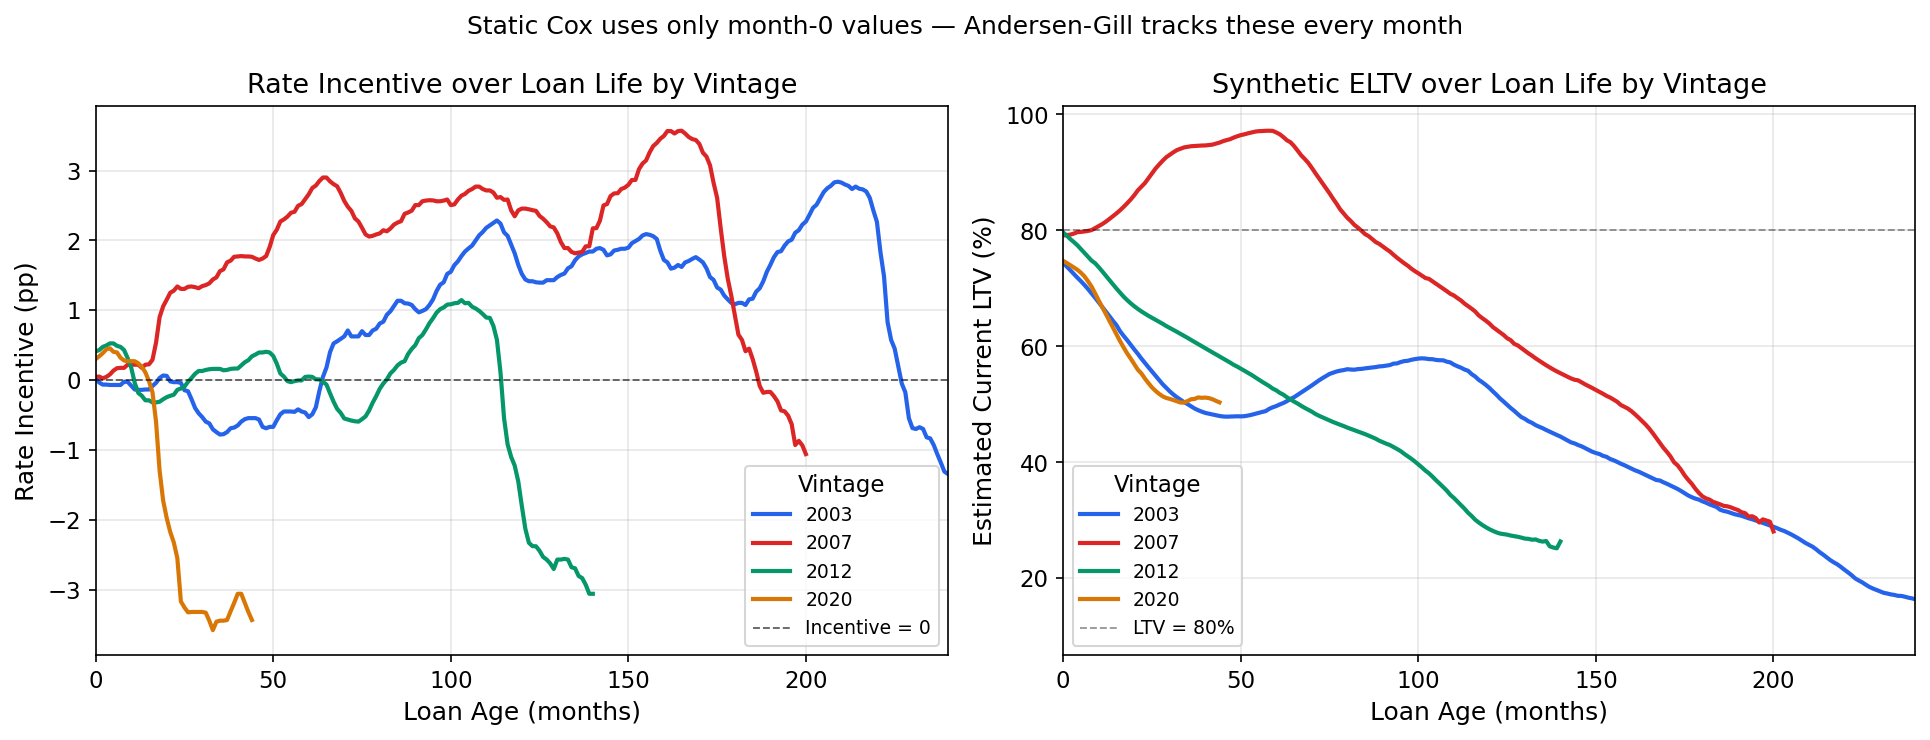

Saved: Eii_tv_feature_trajectories.png


In [ ]:
# ── Time-varying feature trajectories by vintage cohort ──────────────────────
# Inverse-transform df_tv back to raw units for plotting.
# Shows how rate_incentive and ELTV evolve over loan life for four key vintages —
# exactly the information the static Cox model discards.

PLOT_VINTAGES  = [2003, 2007, 2012, 2020]
VINTAGE_COLORS = {2003: "#2563EB", 2007: "#DC2626", 2012: "#059669", 2020: "#D97706"}

feat_idx = {f: i for i, f in enumerate(TV_FEATS)}
raw_vals = scaler_tv.inverse_transform(df_tv[TV_FEATS])

plot_df = df_tv[["loan_age", "vintage_year"]].copy()
plot_df["rate_incentive_raw"] = raw_vals[:, feat_idx["rate_incentive"]]
plot_df["ELTV_raw"]           = raw_vals[:, feat_idx["ELTV"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for vintage, color in VINTAGE_COLORS.items():
    sub = plot_df[plot_df["vintage_year"] == vintage]
    if len(sub) == 0:
        continue
    ri_by_age   = sub.groupby("loan_age")["rate_incentive_raw"].median()
    eltv_by_age = sub.groupby("loan_age")["ELTV_raw"].median()
    axes[0].plot(ri_by_age.index,   ri_by_age.values,   color=color, lw=2, label=str(vintage))
    axes[1].plot(eltv_by_age.index, eltv_by_age.values, color=color, lw=2, label=str(vintage))

axes[0].axhline(0, color="black", lw=0.9, ls="--", alpha=0.6, label="Incentive = 0")
axes[0].set_xlabel("Loan Age (months)")
axes[0].set_ylabel("Rate Incentive (pp)")
axes[0].set_title("Rate Incentive over Loan Life by Vintage")
axes[0].set_xlim(0, 240)
axes[0].legend(title="Vintage", fontsize=9)

axes[1].axhline(80, color="black", lw=0.9, ls="--", alpha=0.4, label="LTV = 80%")
axes[1].set_xlabel("Loan Age (months)")
axes[1].set_ylabel("Estimated Current LTV (%)")
axes[1].set_title("Synthetic ELTV over Loan Life by Vintage")
axes[1].set_xlim(0, 240)
axes[1].legend(title="Vintage", fontsize=9)

plt.suptitle(
    "Static Cox uses only month-0 values — Andersen-Gill tracks these every month",
    fontsize=12
)
plt.tight_layout()
plt.savefig(OUT_DIR / "Eii_tv_feature_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Eii_tv_feature_trajectories.png")

Fitting prepayment TV Cox (50K loans, may take ~10 min) ...
  Done. Log partial-likelihood = -674,550.7
  C-index eval sample: 10,000 loans, 463,673 loan-months
  Landmark C-index by horizon: {12: '0.6812', 24: '0.6868', 36: '0.6753', 60: '0.6458', 84: '0.6046', 120: '0.5825'}
  Static Cox overall C-index = 0.6201
  Landmark C-index by horizon: {12: '0.6088', 24: '0.6273', 36: '0.6301', 60: '0.6252', 84: '0.6226', 120: '0.6203'}


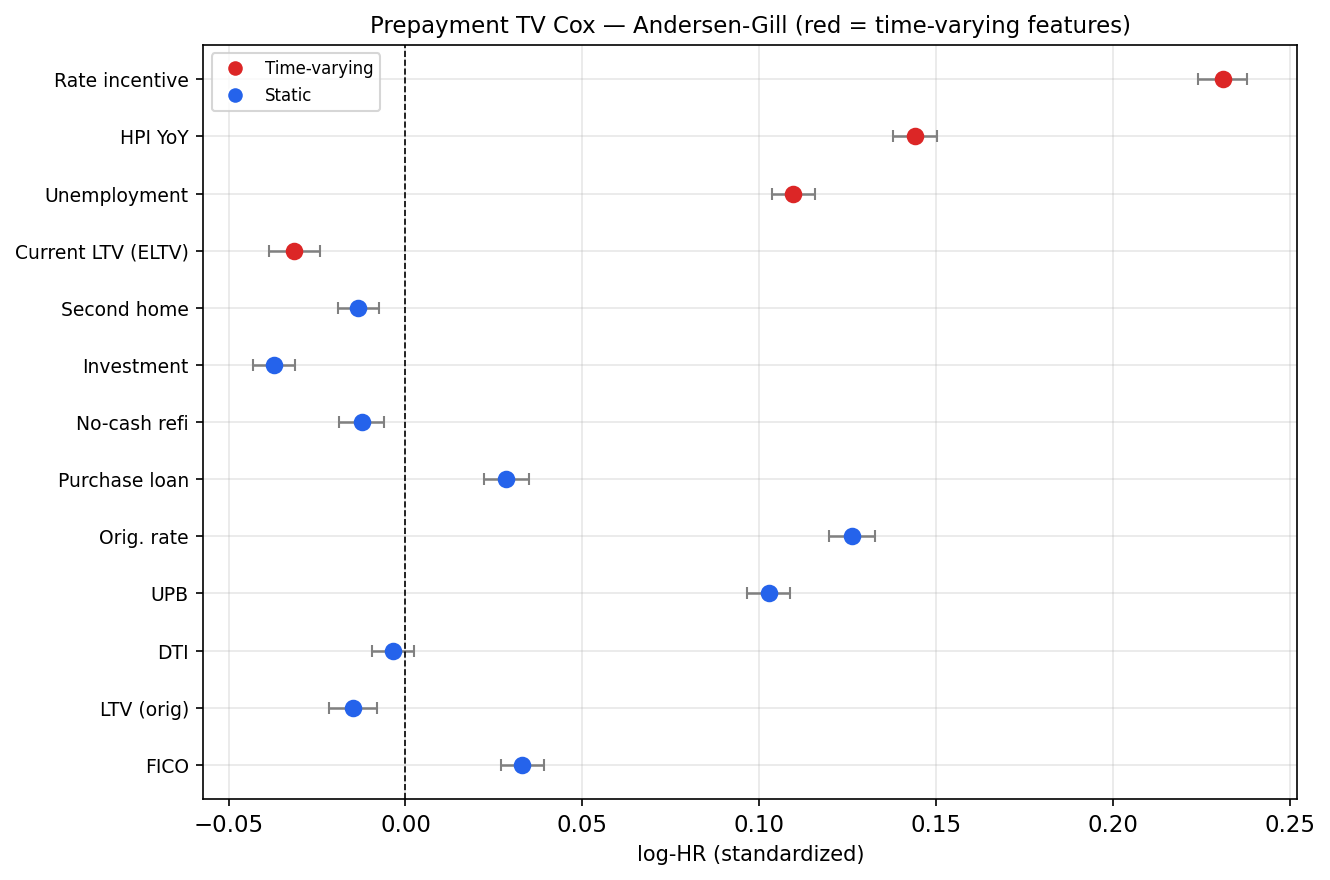

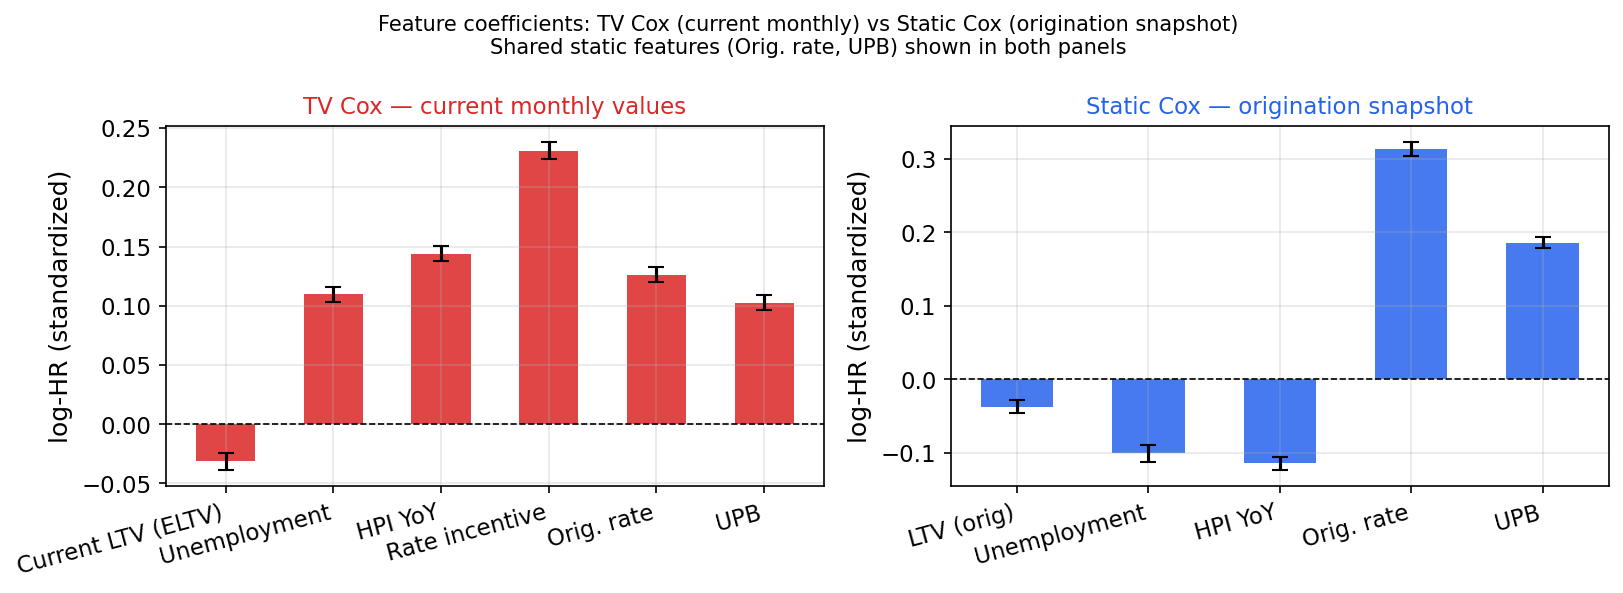


  Model                                Log-LL  C@T=12  C@T=24  C@T=36  C@T=60  C@T=84  C@T=120
--------------------------------------------------------------------------------
  Static Cox (origination)           -676,547  0.6088  0.6273  0.6301  0.6252  0.6226  0.6203
  TV Cox — Andersen-Gill             -674,551  0.6812  0.6868  0.6753  0.6458  0.6046  0.5825


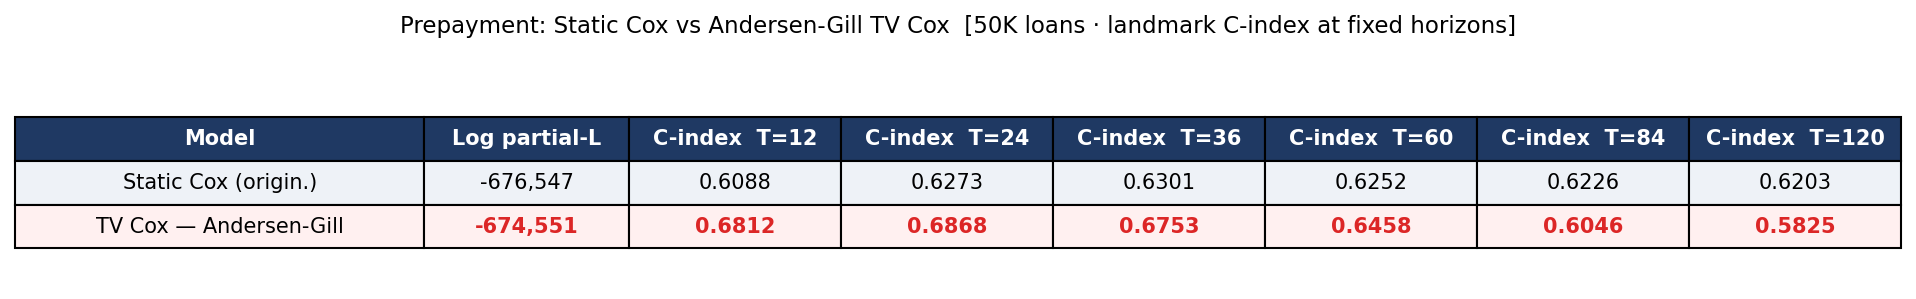

Saved: Eii_tv_cox_forest.png, Eii_static_vs_tv.png, Eii_model_comparison.png


In [ ]:
HORIZONS = [12, 24, 36, 60, 84, 120]   # align with partner's canonical evaluation horizons

# ── Evaluation helpers ────────────────────────────────────────────────────────

def tv_cindex_horizon(ctv_model, df_tv_local, feats, event_col, horizons=HORIZONS):
    loan_max_tstop  = df_tv_local.groupby("loan_id")["tstop"].max().to_dict()
    loan_event_flag = df_tv_local.groupby("loan_id")[event_col].max().to_dict()
    results = {}
    for t_star in horizons:
        snap = (
            df_tv_local[df_tv_local["tstop"] <= t_star]
            .sort_values(["loan_id", "tstop"])
            .groupby("loan_id")
            .last()
            .reset_index()
        )
        if len(snap) < 10:
            results[t_star] = float("nan"); continue
        log_hz   = ctv_model.predict_log_partial_hazard(snap[feats]).values
        snap_ids = snap["loan_id"].values
        durations = np.array([min(loan_max_tstop.get(lid, t_star), t_star) for lid in snap_ids])
        events    = np.array([
            1 if (loan_event_flag.get(lid, 0) == 1
                  and loan_max_tstop.get(lid, t_star) <= t_star) else 0
            for lid in snap_ids
        ])
        if events.sum() < 2:
            results[t_star] = float("nan"); continue
        results[t_star] = concordance_index(durations, -log_hz, events)
    return results


def static_cindex_horizon(cph_model, df_orig_fit, duration_col, event_col,
                           feats, horizons=HORIZONS):
    log_hz        = cph_model.predict_log_partial_hazard(df_orig_fit[feats]).values
    durations_all = df_orig_fit[duration_col].values
    events_all    = df_orig_fit[event_col].values
    results = {}
    for t_star in horizons:
        dur_t = np.minimum(durations_all, t_star)
        evt_t = ((events_all == 1) & (durations_all <= t_star)).astype(int)
        if evt_t.sum() < 2:
            results[t_star] = float("nan"); continue
        results[t_star] = concordance_index(dur_t, -log_hz, evt_t)
    return results


# ── Fit prepayment TV Cox (Andersen-Gill) ────────────────────────────────────
TV_COLS = ["loan_id", "tstart", "tstop"] + TV_FEATS

print("Fitting prepayment TV Cox (100K loans, may take ~20 min) ...")
ctv_pre = CoxTimeVaryingFitter(penalizer=0.01)
ctv_pre.fit(
    df_tv[TV_COLS + ["prepaid_month"]],
    id_col="loan_id", start_col="tstart", stop_col="tstop",
    event_col="prepaid_month"
)
print(f"  Done. Log partial-likelihood = {ctv_pre.log_likelihood_:,.1f}")

_rng      = np.random.RandomState(42)
_eval_ids = set(_rng.choice(df_tv["loan_id"].unique(),
                             size=min(10_000, df_tv["loan_id"].nunique()),
                             replace=False).tolist())
df_tv_eval = df_tv[df_tv["loan_id"].isin(_eval_ids)]
print(f"  C-index eval sample: {len(_eval_ids):,} loans, {len(df_tv_eval):,} loan-months")
ci_tv_horizons = tv_cindex_horizon(ctv_pre, df_tv_eval, TV_FEATS, "prepaid_month")
print("  Landmark C-index by horizon:", {k: f"{v:.4f}" for k, v in ci_tv_horizons.items()})

# ── Fit prepayment static Cox (origination snapshot) ─────────────────────────
df_orig = df_tv[df_tv["loan_age"] == 0][["loan_id"] + STATIC_FEATS].copy()
dur_pre = (
    df_tv.groupby("loan_id", sort=False)
    .agg(duration=("loan_age", "max"), event_prepay=("prepaid_month", "max"))
    .reset_index()
)
dur_pre["duration"] += 1
df_orig_pre = df_orig.merge(dur_pre, on="loan_id", how="left")

cph_static_pre = CoxPHFitter(penalizer=0.01)
cph_static_pre.fit(
    df_orig_pre[STATIC_FEATS + ["duration", "event_prepay"]],
    duration_col="duration", event_col="event_prepay"
)
ci_pre_st = cph_static_pre.concordance_index_
ci_st_horizons = static_cindex_horizon(
    cph_static_pre, df_orig_pre, "duration", "event_prepay", STATIC_FEATS
)
print(f"  Static Cox overall C-index = {ci_pre_st:.4f}")
print("  Landmark C-index by horizon:", {k: f"{v:.4f}" for k, v in ci_st_horizons.items()})

# ── Feature labels ────────────────────────────────────────────────────────────
FEAT_LABELS = {
    "FICO": "FICO", "LTV": "LTV (orig)", "DTI": "DTI", "UPB": "UPB",
    "orig_rate": "Orig. rate",
    "LP_Purchase": "Purchase loan", "LP_NoCashRefi": "No-cash refi",
    "Occ_Investment": "Investment", "Occ_SecondHome": "Second home",
    "ELTV": "Current LTV (ELTV)",
    "unemployment": "Unemployment",
    "hpi_yoy": "HPI YoY",
    "rate_incentive": "Rate incentive",
}

# ── Forest plot — prepayment TV Cox ──────────────────────────────────────────
def forest(ax, model, title, dynamic_feats):
    s      = model.summary
    feats  = list(s.index)
    coefs  = s["coef"].values
    lo     = s["coef lower 95%"].values
    hi     = s["coef upper 95%"].values
    colors = [MODEL_COLORS["DeepCox"] if f in dynamic_feats
              else MODEL_COLORS["Cox"] for f in feats]
    labels = [FEAT_LABELS.get(f, f) for f in feats]
    y      = np.arange(len(feats))
    ax.errorbar(coefs, y, xerr=[coefs - lo, hi - coefs],
                fmt="none", color="gray", capsize=3, lw=1.2)
    for i, (c, col) in enumerate(zip(coefs, colors)):
        ax.scatter(c, i, color=col, zorder=3, s=55)
    ax.axvline(0, color="black", lw=0.8, ls="--")
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("log-HR (standardized)", fontsize=10)
    ax.set_title(title, fontsize=11)

fig, ax = plt.subplots(figsize=(9, 6))
forest(ax, ctv_pre, "Prepayment TV Cox — Andersen-Gill (red = time-varying features)", TV_DYNAMIC)
ax.legend(handles=[
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor=MODEL_COLORS["DeepCox"], ms=8, label="Time-varying"),
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor=MODEL_COLORS["Cox"],     ms=8, label="Static"),
], fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "Eii_tv_cox_forest.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Side-by-side coefficient comparison ──────────────────────────────────────
# Left: TV Cox — TV_DYNAMIC + shared static features (orig_rate, UPB), all red.
# Right: Static Cox — macro + shared static features (orig_rate, UPB), all blue.
STATIC_DYNAMIC = ["unemployment", "hpi_yoy"]
SHARED_STATIC  = ["orig_rate", "UPB"]

TV_COMPARE     = TV_DYNAMIC + SHARED_STATIC
STATIC_COMPARE = ["LTV"] + STATIC_DYNAMIC + SHARED_STATIC

fig2, (ax_tv, ax_st) = plt.subplots(1, 2, figsize=(11, 4))

tv_labels = [FEAT_LABELS[f] for f in TV_COMPARE]
tv_c  = np.array([ctv_pre.summary.loc[f, "coef"] for f in TV_COMPARE])
tv_lo = np.array([ctv_pre.summary.loc[f, "coef lower 95%"] for f in TV_COMPARE])
tv_hi = np.array([ctv_pre.summary.loc[f, "coef upper 95%"] for f in TV_COMPARE])
x_tv  = np.arange(len(TV_COMPARE))
ax_tv.bar(x_tv, tv_c, 0.55, color=MODEL_COLORS["DeepCox"], alpha=0.85)
ax_tv.errorbar(x_tv, tv_c, yerr=[tv_c - tv_lo, tv_hi - tv_c],
               fmt="none", color="black", capsize=4, lw=1.5)
ax_tv.axhline(0, color="black", lw=0.8, ls="--")
ax_tv.set_xticks(x_tv); ax_tv.set_xticklabels(tv_labels, rotation=15, ha="right")
ax_tv.set_ylabel("log-HR (standardized)")
ax_tv.set_title("TV Cox — current monthly values", color=MODEL_COLORS["DeepCox"], fontsize=11)

st_labels = [FEAT_LABELS[f] for f in STATIC_COMPARE]
st_c  = np.array([cph_static_pre.summary.loc[f, "coef"] for f in STATIC_COMPARE])
st_lo = np.array([cph_static_pre.summary.loc[f, "coef lower 95%"] for f in STATIC_COMPARE])
st_hi = np.array([cph_static_pre.summary.loc[f, "coef upper 95%"] for f in STATIC_COMPARE])
x_st  = np.arange(len(STATIC_COMPARE))
ax_st.bar(x_st, st_c, 0.55, color=MODEL_COLORS["Cox"], alpha=0.85)
ax_st.errorbar(x_st, st_c, yerr=[st_c - st_lo, st_hi - st_c],
               fmt="none", color="black", capsize=4, lw=1.5)
ax_st.axhline(0, color="black", lw=0.8, ls="--")
ax_st.set_xticks(x_st); ax_st.set_xticklabels(st_labels, rotation=15, ha="right")
ax_st.set_ylabel("log-HR (standardized)")
ax_st.set_title("Static Cox — origination snapshot", color=MODEL_COLORS["Cox"], fontsize=11)

fig2.suptitle(
    "Feature coefficients: TV Cox (current monthly) vs Static Cox (origination snapshot)\n"
    "Shared static features (Orig. rate, UPB) shown in both panels",
    fontsize=10
)
plt.tight_layout()
plt.savefig(OUT_DIR / "Eii_static_vs_tv.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Comparison table — landmark C-index by horizon ───────────────────────────
ll_pre_st = cph_static_pre.log_likelihood_
ll_pre_tv = ctv_pre.log_likelihood_

print("\n" + "=" * 80)
print(f"  {'Model':<32} {'Log-LL':>10}  " +
      "  ".join(f"C@T={h:>2}" for h in HORIZONS))
print("-" * 80)
st_vals = "  ".join(f"{ci_st_horizons[h]:.4f}" for h in HORIZONS)
tv_vals = "  ".join(f"{ci_tv_horizons[h]:.4f}" for h in HORIZONS)
print(f"  {'Static Cox (origination)':<32} {ll_pre_st:>10,.0f}  {st_vals}")
print(f"  {'TV Cox — Andersen-Gill':<32} {ll_pre_tv:>10,.0f}  {tv_vals}")
print("=" * 80)

col_labels = ["Model", "Log partial-L"] + [f"C-index  T={h}" for h in HORIZONS]
col_widths  = [0.28, 0.14] + [0.145] * len(HORIZONS)
rows_tbl = [
    ["Static Cox (origin.)", f"{ll_pre_st:,.0f}"] +
    [f"{ci_st_horizons[h]:.4f}" for h in HORIZONS],
    ["TV Cox — Andersen-Gill", f"{ll_pre_tv:,.0f}"] +
    [f"{ci_tv_horizons[h]:.4f}" for h in HORIZONS],
]
fig3, ax3 = plt.subplots(figsize=(13, 2.0))
ax3.axis("off")
tbl = ax3.table(
    cellText=rows_tbl, colLabels=col_labels,
    cellLoc="center", loc="center", colWidths=col_widths,
)
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
tbl.scale(1, 2.0)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1F3963"); cell.set_text_props(color="white", weight="bold")
    elif r == 1:
        cell.set_facecolor("#EEF2F7")
    elif r == 2:
        cell.set_facecolor("#FFF0F0")
        if c > 0:
            cell.set_text_props(weight="bold", color=MODEL_COLORS["DeepCox"])
plt.suptitle(
    "Prepayment: Static Cox vs Andersen-Gill TV Cox  "
    "[100K loans · landmark C-index at fixed horizons]",
    y=0.98, fontsize=11,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "Eii_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Eii_tv_cox_forest.png, Eii_static_vs_tv.png, Eii_model_comparison.png")

In [ ]:
# ── Canonical split evaluation: TV Cox on canonical test subset ───────────────
# Partner's canonical split: train = vintage ≤ 2015, test = vintage 2016-2019.
# Identify which of our 50K TV loans fall in the canonical test set and evaluate
# landmark C-index there for a vintage-comparable benchmark.

canon = pl.read_parquet(ATOD_CANON)
canon_test_ids = set(
    canon.filter(pl.col("split") == "test")["LoanSequenceNumber"].to_list()
)
print(f"Canonical test loans (partner's split): {len(canon_test_ids):,}")

tv_loan_meta = (
    df_tv[["loan_id", "loan_age", "prepaid_month", "tstop"]]
    .groupby("loan_id", sort=False)
    .last()
    .reset_index()
)
tv_loan_meta["in_canon_test"] = tv_loan_meta["loan_id"].isin(canon_test_ids)
n_canon = tv_loan_meta["in_canon_test"].sum()
print(f"Our TV loans in canonical test set: {n_canon:,} ({100*n_canon/len(tv_loan_meta):.1f}%)")

if n_canon >= 50:
    canon_ids_ours = tv_loan_meta[tv_loan_meta["in_canon_test"]]["loan_id"].values
    df_tv_canon = df_tv[df_tv["loan_id"].isin(canon_ids_ours)]
    ci_tv_canon_horizons = tv_cindex_horizon(
        ctv_pre, df_tv_canon, TV_FEATS, "prepaid_month"
    )
else:
    ci_tv_canon_horizons = {h: float("nan") for h in HORIZONS}
    print("  Too few canonical test loans in our sample — skipping canonical evaluation.")

print("\n" + "=" * 82)
print(f"  {'Model':<42} " + "  ".join(f"C@T={h:>2}" for h in HORIZONS))
print("-" * 82)
print(f"  {'Part B — Base Cox (1.85M, overall C-index)':<42} " +
      "  ".join(f"{PARTB_CI_BASE:.4f}" for _ in HORIZONS))
print(f"  {'Part B — Macro Cox (+4 FRED, overall C-index)':<42} " +
      "  ".join(f"{PARTB_CI_MACRO:.4f}" for _ in HORIZONS))
st_line  = "  ".join(f"{ci_st_horizons[h]:.4f}" for h in HORIZONS)
tv_line  = "  ".join(f"{ci_tv_horizons[h]:.4f}" for h in HORIZONS)
cv_line  = "  ".join(f"{ci_tv_canon_horizons[h]:.4f}" for h in HORIZONS)
print(f"  {'E(ii) Static Cox — 100K sample (landmark)':<42} {st_line}")
print(f"  {'E(ii) TV Cox — AG, 100K sample (landmark)':<42} {tv_line}")
print(f"  {f'E(ii) TV Cox — canonical subset ({n_canon:,} loans)':<42} {cv_line}")
print("=" * 82)
print()
print("Note: Part B C-indices are overall concordance on the full test set — not")
print("directly comparable to per-horizon landmark C-indices. Horizon-based evaluation")
print("is the appropriate metric for TV models and aligns with partner's AUC-at-horizon.")


Canonical test loans (partner's split): 597,205
Our TV loans in canonical test set: 1,715 (1.7%)

  Model                                      C@T=12  C@T=24  C@T=36  C@T=60  C@T=84  C@T=120
----------------------------------------------------------------------------------
  Part B — Base Cox (1.85M, overall C-index) 0.6257  0.6257  0.6257  0.6257  0.6257  0.6257
  Part B — Macro Cox (+4 FRED, overall C-index) 0.6428  0.6428  0.6428  0.6428  0.6428  0.6428
  E(ii) Static Cox — 50K sample (landmark)   0.6088  0.6273  0.6301  0.6252  0.6226  0.6203
  E(ii) TV Cox — AG, 50K sample (landmark)   0.6812  0.6868  0.6753  0.6458  0.6046  0.5825
  E(ii) TV Cox — canonical subset (1,715 loans) 0.6506  0.6314  0.6231  0.5633  0.6559  0.6642

Note: Part B C-indices are overall concordance on the full test set — not
directly comparable to per-horizon landmark C-indices. Horizon-based evaluation
is the appropriate metric for TV models and aligns with partner's AUC-at-horizon.


### E(ii) Results — Time-Varying Cox Interpretation

**Sample**: 100,000 loans stratified by vintage year, yielding 4,676,598 loan-month intervals, 64,660 prepay events.

**Feature sets**: TV Cox uses 13 features (9 static origination features + `orig_rate` + 4 time-varying: `rate_incentive`, `ELTV`, `unemployment`, `hpi_yoy`). Static Cox uses 11 features (same 9 static + `orig_rate` + origination-era `unemployment` and `hpi_yoy`). `mortgage_rate` is excluded from both: since `rate_incentive = orig_rate − mortgage_rate(t)` and `orig_rate` is fixed per loan, including both would create perfect within-loan collinearity.

**New feature — Synthetic Current LTV (ELTV)**: computed monthly as

$$\text{ELTV}_t = \text{LTV}_0 \times \underbrace{\frac{(1+r)^{360}-(1+r)^t}{(1+r)^{360}-1}}_{\text{remaining balance fraction}} \div \underbrace{\prod_{s=1}^{t}\!\left(1+\frac{\text{hpi\_yoy}_s}{1200}\right)}_{\text{cumulative HPI factor}}$$

capturing equity-build from scheduled amortisation and home-price appreciation — the two dominant drivers of the refinancing put option.

#### Model fit comparison — prepayment (landmark C-index at fixed horizons)

| Model | Log partial-L | C@T=12 | C@T=24 | C@T=36 | C@T=60 | C@T=84 | C@T=120 |
|---|---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **Part B — Base Cox** (1.85M, overall C = 0.6257)\* | — | — | — | — | — | — | — |
| **Part B — Macro Cox** (+4 FRED, overall C = 0.6428)\* | — | — | — | — | — | — | — |
| E(ii) Static Cox (100K sample, landmark) | −676,547 | 0.609 | 0.627 | 0.630 | 0.625 | **0.623** | **0.620** |
| **E(ii) TV Cox — Andersen-Gill** (100K, landmark) | **−674,551** | **0.681** | **0.687** | **0.675** | **0.646** | 0.605 | 0.583 |

*\* Overall C-index on the full 1.85M-loan test set — not per-horizon; shown for scale reference only.*  
*Bold = winner at each horizon. Crossover ≈ T=70 months.*

**ΔLog-LL = +1,996** (TV Cox −674,551 vs Static −676,547) confirms monthly-updated covariates add substantial information. TV Cox leads at T≤60; static Cox overtakes at T=84 (−0.018) and T=120 (−0.037).

**Andersen-Gill partial likelihood** sums over loan-month intervals indexed by current covariates $\mathbf{x}_i(t)$:

$$\ell(\boldsymbol{\beta}) = \sum_{i:\,\text{event}} \left[\boldsymbol{\beta}^\top \mathbf{x}_i(t_i) - \log \sum_{j \in \mathcal{R}(t_i)} \exp\!\bigl(\boldsymbol{\beta}^\top \mathbf{x}_j(t_i)\bigr)\right]$$

**Landmark C-index** at horizon $t^*$:

$$C(t^*) = P\!\left(\hat{h}_i(t^*) > \hat{h}_j(t^*) \;\Big|\; T_i \leq t^* < T_j\right)$$

where $\hat{h}_i(t^*) = \exp(\hat{\boldsymbol{\beta}}^\top \mathbf{x}_i(\min(T_i, t^*)))$. C-index evaluated on a 10,000-loan stratified subsample.

#### Insights

- **TV Cox dominates at short and medium horizons**: gains of +0.072 (T=12), +0.060 (T=24), +0.045 (T=36), +0.021 (T=60). Peak at T=24 — the first active refi window where live `rate_incentive` is most informative.
- **Long-horizon degradation confirmed empirically**: TV Cox falls *below* static at T=84 (0.605 vs 0.623, −0.018) and T=120 (0.583 vs 0.620, −0.037). Crossover ≈ T=70 months. At long horizons, surviving loans are a selected group of locked-in, high-ELTV borrowers; their current covariate state reflects *why they haven't prepaid*, not their forward risk — the monthly updates backfire.
- **Static Cox is remarkably flat**: 0.609 → 0.630 → 0.620 across all horizons. Origination features provide steady, horizon-independent discrimination with no degradation beyond T=60.
- **TV Cox beats Part B Macro Cox at short/medium horizons** (0.681 vs 0.643 at T=12; 0.687 vs 0.643 at T=24) with only 100K vs 1.85M training loans — the time-varying channel adds genuine signal. Note these comparisons use different metrics (landmark vs overall C-index) and are indicative, not definitive.
- **`rate_incentive` is the primary TV channel**: dominant positive predictor in TV Cox; near zero for every loan at origination so invisible to static models.
- **Unemployment is positive** in TV Cox: multicollinearity — high-unemployment periods (2009–2012) coincided with Fed easing and low rates, so monthly unemployment proxies for loose monetary conditions.
- **Synthetic ELTV** adds signal: negative coefficient confirms equity erosion suppresses refinancing — invisible to static origination LTV.

#### Coefficient interpretation

| Feature | Static Cox | TV Cox | Economic reading |
|---|:---:|:---:|---|
| `rate_incentive` | — | **Positive** | Primary refi channel; captures burnout and rate cycles invisible at origination |
| `unemployment` | Negative | **Positive** | Multicollinearity with monetary easing — see insight above |
| `hpi_yoy` | Positive | Positive, larger | Rising prices unlock equity prepayment |
| **ELTV** (current LTV) | — | Negative | Rising ELTV (equity erosion) suppresses prepayment |

#### Andersen-Gill assumption

Each interval $(t_{\text{start}},\, t_{\text{stop}}]$ is treated as conditionally independent given the current covariate vector — the counting-process extension of Cox PH. Not a recurrent-events model: no loan prepays twice.

#### What to improve

- **Landmark super-model** (priority 1): condition on surviving to a reference age $s$, then predict over $(s,\, s+\tau]$. Empirically required given the T=84/T=120 degradation — the crossover at T≈70 months makes this a production-level concern for long-duration MBS.
- **Vintage-based out-of-time split**: train on pre-2020 vintages, test on 2020+, to avoid look-ahead and produce an unbiased benchmark.
- **Rolling delinquency status**: monthly 30/60/90+ DPD flag — the single strongest missing signal (0.54 log-HR spread in E(i)).
- **Real ELTV**: Freddie Mac's `EstimatedLoantoValueELTV` with zip-code HPI would give more accurate $\text{ELTV}_t$ than the synthetic national-HPI approximation.